(200,)
(200,)


Text(0.5, 1.0, 'Scatter Plot of Noisy Linear Data')

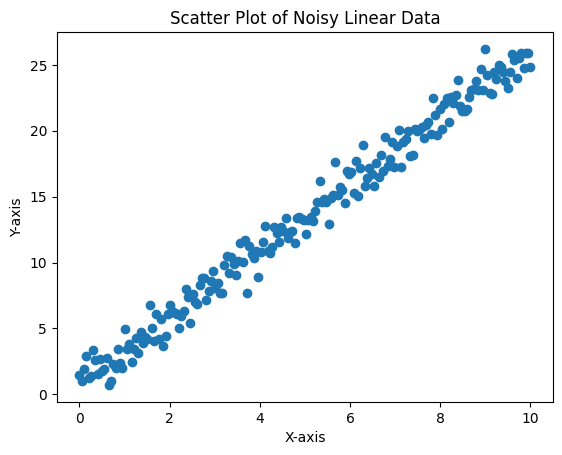

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
np.random.seed(42)  # For reproducibility
noise = np.random.normal(0,1, size=200) #normal(location=0, scale=1, size=100) where scale = std dev and location = center
#size = how many random numbers to generate 
x = np.linspace(0,10,200)
y = (2.5*x)+1+noise
print(x.shape)
print(y.shape)
plt.scatter(x,y)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Scatter Plot of Noisy Linear Data')

In [53]:
#split data into training and validation sets 
indices = np.random.permutation(len(x)) # this shuffles the indices of the data points
xtrain = x[indices[:-40]] # take all but the last 40 indices for training
ytrain = y[indices[:-40]] # corresponding y values for training
xval = x[indices[160:]] # take the last 40 indices for validation
yval = y[indices[160:]] # corresponding y values for validation
print(xtrain.shape)
print(ytrain.shape)
print(xval.shape)
print(yval.shape)

(160,)
(160,)
(40,)
(40,)


Weight: 2.524035746576862
Bias: 0.8582556245386521


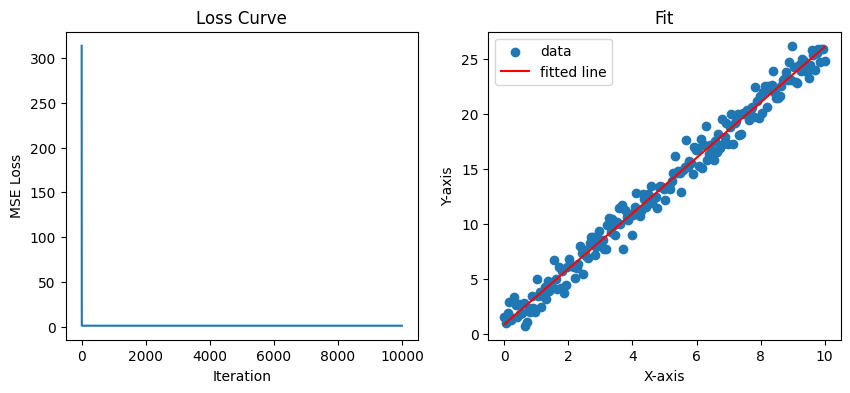

In [54]:
#training 
w = np.random.randn() #random weight
b = np.random.randn() #random bias
loss = np.sum((ytrain-(w*xtrain+b))**2)/len(xtrain) #loss function = MSE
loss_history =[] #list to store loss values
loss_history.append(loss) #append initial loss value to the list
lr =0.01 #learning rate 
for i in range(10000): #number of iterations
    w = w - lr*(2/len(xtrain))*np.sum((ytrain-(w*xtrain+b))*(-xtrain)) #gradient descent update for weight
    b = b - lr*(2/len(xtrain))*np.sum((ytrain-(w*xtrain+b))*(-1)) #gradient descent update for bias
    loss1 = np.sum((ytrain-(w*xtrain+b))**2)/len(xtrain)
    loss_history.append(loss1)
print ("Weight:", w)
print ("Bias:", b)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

axes[0].plot(loss_history)
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE Loss')

axes[1].scatter(x, y, label='data')
x_line = np.linspace(0, 10, 100)   # x-range spanning your data
y_line = w * x_line + b            # apply your learned equation
axes[1].plot(x_line, y_line, color='red', label='fitted line')
axes[1].set_title('Fit')
axes[1].set_xlabel('X-axis')
axes[1].set_ylabel('Y-axis')
axes[1].legend()

plt.show()

In [55]:
#validation
loss_train = np.sum((ytrain-(w*xtrain+b))**2)/len(xtrain)
loss_val = np.sum((yval-(w*xval+b))**2)/len(xval)
print("Training Loss:", loss_train)
print("Validation Loss:", loss_val)

Training Loss: 0.8767178812276508
Validation Loss: 0.7853299782029118


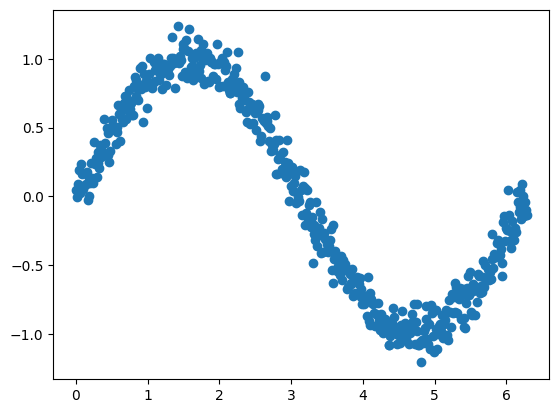

In [56]:
#Part B
np.random.seed(42)  # For reproducibility
noise = np.random.normal(0,1, size=500) 
xb = np.linspace(0,2*np.pi,500)
yb = np.sin(xb) + 0.1*noise
indices = np.random.permutation(len(xb)) # this shuffles the indices of the data points
#training and validation split
xb_train = xb[indices[:400]] # take all but the last 100 indices for training
yb_train = yb[indices[:400]] # corresponding y values for training
xb_val = xb[indices[400:500]] # take the last 100 indices for validation
yb_val = yb[indices[400:500]] # corresponding y values for validation
plt.scatter(xb,yb)

In [57]:
np.random.seed(42)  # For reproducibility
w1 = np.random.randn(64)*0.5#random weight
w2 = np.random.randn(64)*0.5 #random weight
b1 = np.random.randn(64)*0.5 #random bias
b2 = np.random.randn(1)*0.5 #random bias
def forward(x, w1, b1, w2, b2):
    z = w1*x + b1 # shape (64,)
    a = np.maximum(0, z)# ReLU applied to z, shape (64,)
    y_hat = np.sum(w2*a) + b2  # scalar
    return y_hat, z, a
y_hat, z, a = forward(2, w1, b1, w2, b2)
print(y_hat)
print(z.shape)
print(a.shape)

def backward(x, y, y_hat, z, a, w2):
    delta2 = 2*(y_hat-y)                         # scalar
    grad_w2 = delta2 * a                       # shape (64,) -- delta2 * a
    grad_b2 = delta2                         # scalar -- just delta2

    delta1 = delta2 * w2 * (z>0)                          # shape (64,) -- delta2 * w2 * (z>0)
    grad_w1 = delta1 * x                         # shape (64,) -- delta1 * x
    grad_b1 = delta1                         # shape (64,) -- delta1

    return grad_w1, grad_b1, grad_w2, grad_b2
grad_w1, grad_b1, grad_w2, grad_b2 = backward(2, np.sin(2), y_hat, z, a, w2)
print (grad_w1.shape)
print (grad_b1.shape)
print (grad_w2.shape)
print (grad_b2.shape)





[0.14391434]
(64,)
(64,)
(64,)
(64,)
(64,)
(1,)


Final train loss: 0.02067493375054801
Final val loss: 0.017295623239292977


Text(0.5, 1.0, 'Loss Curves')

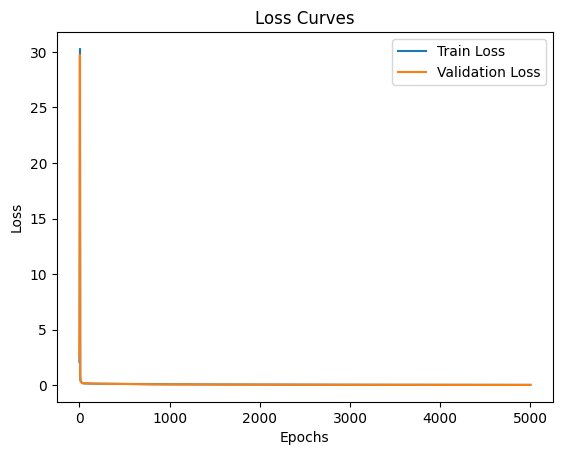

In [58]:
np.random.seed(42)

# reinitialize parameters fresh for training
H = 64
w1 = np.random.randn(H) * 0.5
b1 = np.random.randn(H) * 0.5
w2 = np.random.randn(H) * 0.5
b2 = np.random.randn(1) * 0.5

lr = 0.01          #  learning rate, may need tuning
epochs = 5000       #  pick number of epochs

train_loss_history = []
val_loss_history = []

n_train = len(xb_train)

for epoch in range(epochs):
    grad_w1_total = np.zeros(H)
    grad_b1_total = np.zeros(H)
    grad_w2_total = np.zeros(H)
    grad_b2_total = np.zeros(1)
    train_loss_total = 0.0

    for i in range(n_train):
        x_i = xb_train[i]
        y_i = yb_train[i]

        # forward pass
        y_hat, z, a = forward(x_i, w1, b1, w2, b2)

        # accumulate loss  
        train_loss_total += np.sum((y_i - y_hat) ** 2)

        # backward pass
        grad_w1, grad_b1, grad_w2, grad_b2 = backward(x_i, y_i, y_hat, z, a, w2)

        # accumulate gradients 
        grad_w1_total += (grad_w1)
        grad_b1_total += (grad_b1)
        grad_w2_total += (grad_w2)
        grad_b2_total += (grad_b2)

    # average gradients over all training points  
    grad_w1_avg = grad_w1_total / n_train
    grad_b1_avg = grad_b1_total / n_train
    grad_w2_avg = grad_w2_total / n_train
    grad_b2_avg = grad_b2_total / n_train

    # update parameters using gradient descent  
    w1 = w1 - lr * grad_w1_avg
    b1 = b1 - lr * grad_b1_avg
    w2 = w2 - lr * grad_w2_avg
    b2 = b2 - lr * grad_b2_avg

    # average training loss for this epoch
    train_loss_avg = train_loss_total / n_train
    train_loss_history.append(train_loss_avg)

    #compute validation loss this epoch (loop over xb_val/yb_val similarly,
    # using forward() only — no backward needed for validation — and average the squared errors)
    y_hat_val_total = 0.0
    for i in range(len(xb_val)):
        x_i_val = xb_val[i]
        y_i_val = yb_val[i]
        y_hat_val, _, _ = forward(x_i_val, w1, b1, w2, b2)
        y_hat_val_total += np.sum((y_i_val - y_hat_val) ** 2)/len(xb_val)
    val_loss_avg = y_hat_val_total
    val_loss_history.append(val_loss_avg)

print("Final train loss:", train_loss_history[-1])
print("Final val loss:", val_loss_history[-1])
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curves')

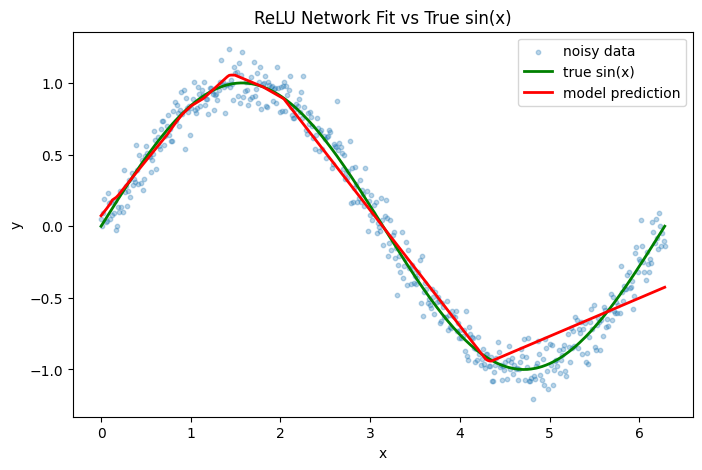

In [59]:
# Step 6: Predictions vs true curve on dense grid
x_grid = np.linspace(0, 2*np.pi, 300)
y_pred_grid = np.array([forward(x, w1, b1, w2, b2)[0] for x in x_grid]).flatten()
y_true_grid = np.sin(x_grid)

plt.figure(figsize=(8,5))
plt.scatter(xb, yb, s=10, alpha=0.3, label='noisy data')
plt.plot(x_grid, y_true_grid, color='green', linewidth=2, label='true sin(x)')
plt.plot(x_grid, y_pred_grid, color='red', linewidth=2, label='model prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.title('ReLU Network Fit vs True sin(x)')
plt.legend()
plt.show()

In [60]:
errors = []
for i in range(len(xb_val)):
    x_i_val = xb_val[i]
    y_i_val = yb_val[i]
    y_hat_val, _, _ = forward(x_i_val, w1, b1, w2, b2)
    errors.append(np.abs(y_i_val - y_hat_val))

errors = np.array(errors)
mae = np.mean(errors)
max_err = np.max(errors)

print("Validation MAE:", mae)
print("Validation Max Absolute Error:", max_err)

Validation MAE: 0.09931181848501397
Validation Max Absolute Error: 0.5004339426510995


## Part C — Connecting to Option Pricing

### 1. Why a linear model shall not suffice for the American put surface

The payoff of an American put at expiry, `max(K − S, 0)`, is already a piecewise-linear affair rather than a single unbroken line — much as the ReLU hinges we constructed in Part B. Prior to expiry, however, the option's price acquires an additional layer of *time value*, and this cushion does not grow in a straightforward, linear fashion; it depends intricately upon how far the stock price `S` sits from the strike `K`, how much time `T` remains, and the prevailing volatility `σ`. This curvature is precisely what is measured by *gamma*, the second derivative of price with respect to `S` — and a linear model, whose second derivative vanishes everywhere, is fundamentally incapable of representing such a quantity. Furthermore, the price surface exhibits genuine interaction between its inputs: the influence of volatility, for instance, is markedly different near the strike than far from it, whereas a linear model presumes every input acts independently and additively. The American put's early-exercise privilege introduces yet another wrinkle — a kink in the surface at the optimal exercise boundary. For these reasons, a linear model would systematically underfit the true pricing surface, in the same manner a straight line failed to capture the gentle curvature of sin(x) — a network of ReLU hinges is required to approximate a surface this nonlinear, interacting, and kinked.

### 2. Five input features for Week 6

I shall employ the following five features, each to be verified against the units used in my Week 4 binomial pricer before training commences:

| Feature | Symbol | Unit |
|---|---|---|
| Underlying stock price | `S` | currency |
| Strike price | `K` | currency (same currency as `S`) |
| Time to expiry | `T` | years |
| Risk-free interest rate | `r` | annualised decimal (e.g. 0.05 for 5%) |
| Volatility | `σ` | annualised decimal (e.g. 0.20 for 20%) |

Before training, I will confirm each feature is expressed in the same units as my Week 4 pricer — most notably, that `T` is given in years and that `r`, `σ` are annualised decimals rather than percentages, since a silent mismatch in units would quietly corrupt the entire training process.

### 3. Sanity check for the trained network (Week 6)

One sanity check I intend to run is a test of **monotonicity in `S`**: holding `K`, `T`, `r`, and `σ` fixed, the predicted put price ought never to *increase* as `S` rises, since a put option grows less valuable the further the stock price climbs above the strike. I will verify this by evaluating the trained network across a fine grid of `S` values and confirming the predictions decline (or remain flat) throughout, alongside a check that every predicted price remains non-negative.